## Surface Evap and Masked Surface Evap

### Read in ERA5 and create a surface evap + land masked surface evap array

** **not using ERA5 Land in this code**

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import scipy
import sys 
import warnings
import matplotlib.pyplot as plt
from shapely.geometry import mapping
import cartopy.crs as ccrs
import cartopy.feature
warnings.filterwarnings('ignore')
import time as timer
start_all = timer.time()

In [ ]:
dataf ="/Volumes/ESA_F4R/era/" 
datao ="/Volumes/ESA_F4R/ed_prepare/2026_mergeds/" 
datap ="/Users/ellendyer/Library/Mobile Documents/com~apple~CloudDocs/1SHARED_WORK/Work/3_ESA_GRANT/MODEL/plots/era/"

In [ ]:
#For selection and plotting
YR = 2010
time_bnds = (str(YR)+'-01-01',str(YR)+'-12-31')
lon_bnds, lat_bnds = (8, 32), (12,-15)
lon_bnds_f, lat_bnds_f = (8, 32), (-15,12) 
p_bnds = (30000,100000)

**Read in ERA5 land-sea mask to use to create a land only version of surface evaporation**

Values greater than 0 are land values which can include water bodies on land such as rivers

<xarray.DataArray 'lsm' (lat: 1801, lon: 3600)> Size: 52MB
[6483600 values with dtype=float64]
Coordinates:
  * lon      (lon) float32 14kB 0.0 0.1 0.2 0.3 0.4 ... 359.6 359.7 359.8 359.9
  * lat      (lat) float32 7kB 90.0 89.9 89.8 89.7 ... -89.7 -89.8 -89.9 -90.0
Attributes:
    units:          (0 - 1)
    long_name:      Land-sea mask
    standard_name:  land_binary_mask


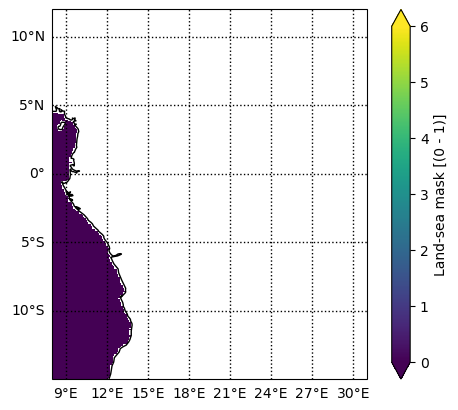

<Figure size 640x480 with 0 Axes>

In [4]:
mask = xr.open_dataset("/Users/ellendyer/Documents/GitHub/f4r-bulk-recycling-model/lsm_1279l4_0.1x0.1.grb_v4_unpack.nc")['lsm']
mask = mask.rename({'latitude':'lat','longitude':'lon'})
mask = mask.squeeze(['time'], drop=True)
print(mask)

mask = mask.where(mask.lon<24.0,1)

water = mask.where(mask==0.0,drop=True)

ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
#ax.add_feature(cartopy.feature.OCEAN)
water.plot(ax=ax,transform=ccrs.PlateCarree(),
                                       add_colorbar=True,
                                       vmin=0,vmax=6,
                                       alpha=1,
                                       cmap=plt.cm.viridis,
                                       extend="both")
ax.set_extent([8, 31, -15, 12])
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='black', alpha=1, linestyle='dotted')
gl.top_labels = False
gl.right_labels = False
ax.set_title('')
#plt.savefig()
plt.show()
plt.clf()

### Not using ERA5 land but keeping the note as the accumulation for ERA5 surface is different - note below

**Read in ERA5 land data (hourly in monthly files)**
- selecting hour 23 (0-23) of Prec and Evap because of how ERA5 Land variables are accumulated (https://confluence.ecmwf.int/pages/viewpage.action?pageId=197702790 - https://confluence.ecmwf.int/display/CKB/ERA5-Land%3A+data+documentation#ERA5Land:datadocumentation-accumulationsAccumulations)
- prec is multiplied by 1000 to convert from m to mm
- evap is multiplied by -1000 to convert from m to mm and upward fluxes in land model are considered negative
- Prec, Evap, and Psfc are then resampled to MS monthly and also interpolated to coarser pressure level grid

**Input file units:**
- tp - m (no longer need this)
- e - m (-)
- sp - pa

**Read in ERA5 surface variables (hourly in monthly files)**
- these files are also accumulation but they are per timestep so the value should be a sum over the day rather than the last time step
- https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels?tab=overview 


Read in ERA5 surface vars for merging - setting non land evaporation to zero. 

In [5]:
start = timer.time()

from functools import partial
def _preprocess_land(x, lon_bnds, lat_bnds):
    x = x.sel(longitude=slice(*lon_bnds), latitude=slice(*lat_bnds),drop=True)
    return x
partial_func_land = partial(_preprocess_land, lon_bnds=lon_bnds, lat_bnds=lat_bnds)

#Reading in surface variables from ERA5 surface files
ds_era_psfc = xr.open_mfdataset(dataf+"era5/era5_surface/era5_surface_pressure_central_africa_"+str(YR)+"*.nc",
                                drop_variables=['expver','number'],
                                preprocess=partial_func_land,parallel=True).load()
ds_era_psfc = ds_era_psfc.rename({'valid_time':'time','latitude':'lat',
                                  'longitude':'lon','sp':'Psfc'})
Psfc_surface = ds_era_psfc['Psfc']/100.0
ds_era_psfc.close()

ds_era_evap = xr.open_mfdataset(dataf+"era5/era5_surface/era5_evaporation_central_africa_"+str(YR)+"*.nc",
                                drop_variables=['expver','number'],
                                preprocess=partial_func_land,parallel=True).load()
ds_era_evap = ds_era_evap.rename({'valid_time':'time','latitude':'lat',
                                  'longitude':'lon','e':'Evap'})
Evap_surface = ds_era_evap.resample(time='D').sum(dim='time')*-1000.0
ds_era_evap.close()

Evap_all = Evap_surface
mask_surf = mask.interp(lat=Evap_surface['lat'],lon=Evap_surface['lon'],method='linear',kwargs={"fill_value": "extrapolate"})
Evap_land = Evap_surface.where(mask_surf!=0.0,0,0)

EvapL = xr.Dataset({"Evap_land":Evap_land['Evap']})
EvapA = xr.Dataset({"Evap_all":Evap_all['Evap']})
Psfc = Psfc_surface

end = timer.time()
length = end - start
print("ERA5 surface data read in took ", length, "seconds")

ERA5 surface data read in took  92.46098494529724 seconds


## Plotting the different evaporation arrays

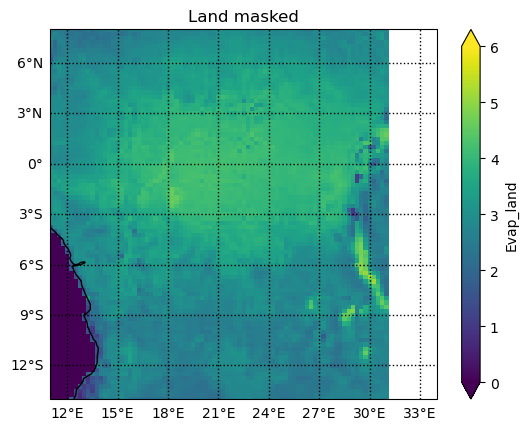

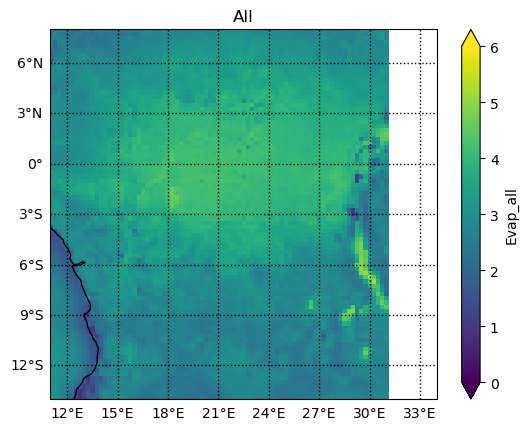

<Figure size 640x480 with 0 Axes>

In [6]:
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
#ax.add_feature(cartopy.feature.OCEAN)
EvapL['Evap_land'].mean('time').plot(ax=ax,transform=ccrs.PlateCarree(),
                                       add_colorbar=True,
                                       vmin=0,vmax=6,
                                       alpha=1,
                                       cmap=plt.cm.viridis,
                                       extend="both")
ax.set_extent([11, 34, -14, 8])
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='black', alpha=1, linestyle='dotted')
gl.top_labels = False
gl.right_labels = False
ax.set_title('Land masked')
#plt.savefig()
plt.show()
plt.clf()


ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
#ax.add_feature(cartopy.feature.OCEAN)
EvapA['Evap_all'].mean('time').plot(ax=ax,transform=ccrs.PlateCarree(),
                                       add_colorbar=True,
                                       vmin=0,vmax=6,
                                       alpha=1,
                                       cmap=plt.cm.viridis,
                                       extend="both")
ax.set_extent([11, 34, -14, 8])
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='black', alpha=1, linestyle='dotted')
gl.top_labels = False
gl.right_labels = False
ax.set_title('All')
#plt.savefig()
plt.show()
plt.clf()


**Merging all input datasets into one dataset for recyling code called ds**
- close both input datasets
- sort everything so latitude is south to north
- transpose dimensions so they run (lon,lat,level,time) as in recycling code
- save input ds to file

In [7]:
start = timer.time()
ds = xr.merge([EvapL,EvapA,Psfc]) 
ds = ds.sortby('lat', ascending=True)
ds = ds.sel(lat=slice(*lat_bnds_f),lon=slice(*lon_bnds_f))


In [8]:
ds = ds.resample(time='MS').mean(dim='time')
ds = ds.transpose("lon", "lat", "level", "time",missing_dims='ignore')

In [9]:
ds.to_netcdf(datao+"merge_erads_S_SE_"+str(YR)+".nc", mode='w', format='NETCDF4', engine='netcdf4')
end = timer.time()
length = end - start
print("Merging and dataset output took ", length, "seconds")

Merging and dataset output took  568.7732701301575 seconds
